In [1]:
# Если вы запускаете ноутбук в "чистом" окружении:
# pip install -U scikit-learn matplotlib numpy
import os
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import json

from sklearn.datasets import load_digits
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans, DBSCAN, AgglomerativeClustering
from sklearn.metrics import (
    silhouette_score,
    davies_bouldin_score,
    calinski_harabasz_score,
    adjusted_rand_score,
    normalized_mutual_info_score,
)

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

In [2]:
# Настройки PCA: None (не использовать) или число компонент (например, 30)
pca_dim = 8

# Диапазон K для KMeans
kmeans_ks = list(range(2, 21))

# Сетка для DBSCAN: eps и min_samples
# eps зависит от масштаба данных – после scaling обычно eps ~ 0.5..5 (но это очень примерно).
dbscan_eps = [0.5, 1.0, 1.5, 2.0, 2.5, 3.0, 3.5]
dbscan_min_samples = [3, 5, 10]

# Agglomerative: число кластеров и linkage (для sklearn Agglomerative: 'ward' требует euclidean)
agg_ks = list(range(2, 21))
agg_linkages = ["ward", "complete", "average"]

print("Config:")
print(" pca_dim:", pca_dim)
print(" kmeans_ks:", (kmeans_ks[0], "...", kmeans_ks[-1]))
print(" dbscan eps:", dbscan_eps)
print(" dbscan min_samples:", dbscan_min_samples)
print(" agg ks:", (agg_ks[0], "...", agg_ks[-1]))
print(" agg linkages:", agg_linkages)

Config:
 pca_dim: 8
 kmeans_ks: (2, '...', 20)
 dbscan eps: [0.5, 1.0, 1.5, 2.0, 2.5, 3.0, 3.5]
 dbscan min_samples: [3, 5, 10]
 agg ks: (2, '...', 20)
 agg linkages: ['ward', 'complete', 'average']


Загрузка данных

In [3]:
data1 = pd.read_csv("data/S07-hw-dataset-01.csv")
data2 = pd.read_csv("data/S07-hw-dataset-02.csv")
data3 = pd.read_csv("data/S07-hw-dataset-03.csv")
data1.head()

,sample_id,f01,f02,f03,f04,f05,f06,f07,f08
0,0,-0.536647,-69.812900,-0.002657,71.743147,-11.396498,-12.291287,-6.836847,-0.504094
1,1,15.230731,52.727216,-1.273634,-104.123302,11.589643,34.316967,-49.468873,0.390356
2,2,18.542693,77.317150,-1.321686,-111.946636,10.254346,25.892951,44.595250,0.325893
3,3,-12.538905,-41.709458,0.146474,16.322124,1.391137,2.014316,-39.930582,0.139297
4,4,-6.903056,61.833444,-0.022466,-42.631335,3.107154,-5.471054,7.001149,0.131213


In [4]:
data2.head()

,sample_id,x1,x2,z_noise
0,0,0.098849,-1.846034,21.288122
1,1,-1.024516,1.829616,6.072952
2,2,-1.094178,-0.158545,-18.938342
3,3,-1.612808,-1.565844,-11.629462
4,4,1.659901,-2.133292,1.895472


In [5]:
data3.head()

,sample_id,x1,x2,f_corr,f_noise
0,0,-2.710470,4.997107,-1.015703,0.718508
1,1,8.730238,-8.787416,3.953063,-1.105349
2,2,-1.079600,-2.558708,0.976628,-3.605776
3,3,6.854042,1.560181,1.760614,-1.230946
4,4,9.963812,-8.869921,2.966583,0.915899


In [6]:
data1.info()
data1.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12000 entries, 0 to 11999
Data columns (total 9 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   sample_id  12000 non-null  int64  
 1   f01        12000 non-null  float64
 2   f02        12000 non-null  float64
 3   f03        12000 non-null  float64
 4   f04        12000 non-null  float64
 5   f05        12000 non-null  float64
 6   f06        12000 non-null  float64
 7   f07        12000 non-null  float64
 8   f08        12000 non-null  float64
dtypes: float64(8), int64(1)
memory usage: 843.9 KB


,sample_id,f01,f02,f03,f04,f05,f06,f07,f08
count,12000.00000,12000.000000,12000.000000,12000.000000,12000.000000,12000.000000,12000.000000,12000.000000,12000.000000
mean,5999.50000,-2.424716,19.107804,-0.222063,-8.284501,-0.190717,0.962972,0.033724,0.007638
std,3464.24595,11.014315,60.790338,0.500630,59.269838,7.026435,14.794713,59.541782,0.607053
min,0.00000,-19.912573,-92.892652,-1.590979,-134.303679,-11.869169,-20.521164,-215.098834,-2.633469
25%,2999.75000,-9.472623,-40.282955,-0.125145,-48.345007,-5.132473,-8.807706,-39.900520,-0.401483
50%,5999.50000,-6.869404,54.069335,-0.031753,16.211728,0.444730,-6.134169,-0.578494,0.005306
75%,8999.25000,0.523841,70.280739,0.054980,28.067178,3.942368,2.334426,39.719821,0.410132
max,11999.00000,24.403381,112.229523,0.512277,75.088604,13.717091,41.452857,213.381767,2.490745


In [7]:
data2.info()
data2.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8000 entries, 0 to 7999
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   sample_id  8000 non-null   int64  
 1   x1         8000 non-null   float64
 2   x2         8000 non-null   float64
 3   z_noise    8000 non-null   float64
dtypes: float64(3), int64(1)
memory usage: 250.1 KB


,sample_id,x1,x2,z_noise
count,8000.00000,8000.000000,8000.000000,8000.000000
mean,3999.50000,0.478867,0.241112,0.110454
std,2309.54541,0.955138,0.663195,8.097716
min,0.00000,-2.487352,-2.499237,-34.056074
25%,1999.75000,-0.116516,-0.242357,-5.392210
50%,3999.50000,0.490658,0.241092,0.132470
75%,5999.25000,1.085263,0.726526,5.655605
max,7999.00000,2.987555,2.995553,29.460076


In [8]:
data3.info()
data3.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15000 entries, 0 to 14999
Data columns (total 5 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   sample_id  15000 non-null  int64  
 1   x1         15000 non-null  float64
 2   x2         15000 non-null  float64
 3   f_corr     15000 non-null  float64
 4   f_noise    15000 non-null  float64
dtypes: float64(4), int64(1)
memory usage: 586.1 KB


,sample_id,x1,x2,f_corr,f_noise
count,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000
mean,7499.500000,1.246296,1.033764,0.212776,-0.027067
std,4330.271354,4.592421,4.710791,1.530017,2.506375
min,0.000000,-9.995585,-9.980853,-5.212038,-8.785884
25%,3749.750000,-1.782144,-2.666393,-0.966224,-1.731128
50%,7499.500000,0.664226,1.831257,0.296508,-0.052391
75%,11249.250000,4.435671,4.969630,1.390273,1.673831
max,14999.000000,16.207863,14.271153,5.795876,11.266865


In [9]:
X1 = data1.drop(['sample_id'], axis=1)
sample_id1  = data1['sample_id'] 
X2 = data2.drop(['sample_id'], axis=1)
sample_id2  = data2['sample_id'] 
X3 = data3.drop(['sample_id'], axis=1)
sample_id3  = data3['sample_id'] 

Препроцессинг: Scaling

In [10]:
scaler = StandardScaler()
X_scaled1 = scaler.fit_transform(X1)
X_scaled2 = scaler.fit_transform(X2)
X_scaled3 = scaler.fit_transform(X3)

def safe_pca_transform(X_scaled, pca_dim):
    """Безопасное применение PCA"""
    if pca_dim is None:
        return X_scaled, None
    
    n_features = X_scaled.shape[1]
    
    # Если запрашиваем больше компонент, чем есть признаков
    if pca_dim >= n_features:
        print(f"Предупреждение: pca_dim={pca_dim} >= признаков={n_features}")
        print("Используем все признаки без уменьшения размерности")
        return X_scaled, None
    
    # Применяем PCA
    pca_model = PCA(n_components=pca_dim, random_state=RANDOM_STATE)
    X_feat = pca_model.fit_transform(X_scaled)
    return X_feat, pca_model

# Применение
X_feat1, pca_model1 = safe_pca_transform(X_scaled1, pca_dim)
X_feat2, pca_model2 = safe_pca_transform(X_scaled2, pca_dim)
X_feat3, pca_model3 = safe_pca_transform(X_scaled3, pca_dim)
print("X_scaled.shape:", X_scaled1.shape)
print("X_feat.shape:", X_feat1.shape)
print("X_scaled.shape:", X_scaled2.shape)
print("X_feat.shape:", X_feat2.shape)
print("X_scaled.shape:", X_scaled3.shape)
print("X_feat.shape:", X_feat3.shape)

Предупреждение: pca_dim=8 >= признаков=8
Используем все признаки без уменьшения размерности
Предупреждение: pca_dim=8 >= признаков=3
Используем все признаки без уменьшения размерности
Предупреждение: pca_dim=8 >= признаков=4
Используем все признаки без уменьшения размерности
X_scaled.shape: (12000, 8)
X_feat.shape: (12000, 8)
X_scaled.shape: (8000, 3)
X_feat.shape: (8000, 3)
X_scaled.shape: (15000, 4)
X_feat.shape: (15000, 4)


Функции оценки и визуализации

In [11]:
def safe_cluster_metrics(X, labels):
    """Считает метрики; возвращает None, если метрика неприменима."""
    unique = np.unique(labels)
    # Нужно минимум 2 кластера
    if len(unique) < 2:
        return None

    # Нельзя, чтобы все точки были в одном кластере
    if len(unique) == 1:
        return None

    # silhouette требует, чтобы все кластеры имели >1 точки (часто, но не всегда)
    # В sklearn silhouette_score может падать, если какой-то кластер пуст/особый.
    try:
        sil = float(silhouette_score(X, labels))
    except Exception:
        sil = None

    try:
        db = float(davies_bouldin_score(X, labels))
    except Exception:
        db = None

    try:
        ch = float(calinski_harabasz_score(X, labels))
    except Exception:
        ch = None

    return {"silhouette": sil, "davies_bouldin": db, "calinski_harabasz": ch}

def pca_2d_for_plot(X_scaled, random_state=RANDOM_STATE):
    """PCA(2D) именно для визуализации."""
    p = PCA(n_components=2, random_state=random_state)
    return p.fit_transform(X_scaled)

def plot_2d_embedding(emb2d, labels, title):
    plt.figure(figsize=(7, 5))
    plt.scatter(emb2d[:, 0], emb2d[:, 1], c=labels, s=18)
    plt.title(title)
    plt.xlabel("dim-1")
    plt.ylabel("dim-2")
    plt.grid(True, alpha=0.2)
    plt.show()

def summarize_labels(labels):
    unique, counts = np.unique(labels, return_counts=True)
    return dict(zip(unique.tolist(), counts.tolist()))


KMeans

In [12]:
def eval_kmeans_grid(X_feat, ks):
    results = []
    for k in ks:
        try:
            model = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init="auto")
        except TypeError:
            model = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10)

        labels = model.fit_predict(X_feat)
        metrics = safe_cluster_metrics(X_feat, labels)

        results.append({
            "algo": "kmeans",
            "params": {"k": k},
            "labels": labels,
            "metrics": metrics,
            "inertia": float(model.inertia_),
            "n_clusters": len(np.unique(labels)),
            "noise_frac": 0.0,
        })
    return results

kmeans_results1 = eval_kmeans_grid(X_feat1, kmeans_ks)
len(kmeans_results1), kmeans_results1[0]["params"], kmeans_results1[-1]["params"]

(19, {'k': 2}, {'k': 20})

График 1 сохранен: ./artifacts/figures/dataset3_kmeans_silhouette.png


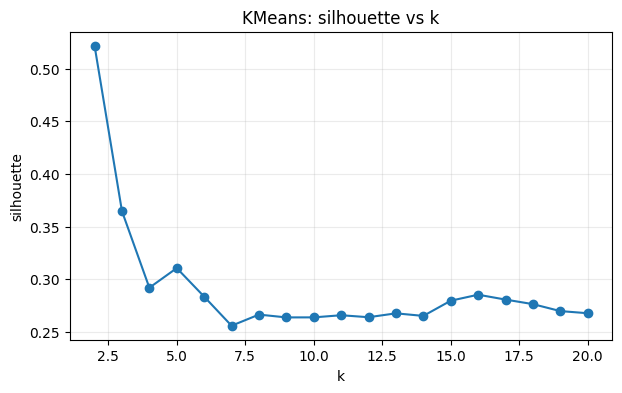

График 2 сохранен: ./artifacts/figures/dataset3_kmeans_elbow.png


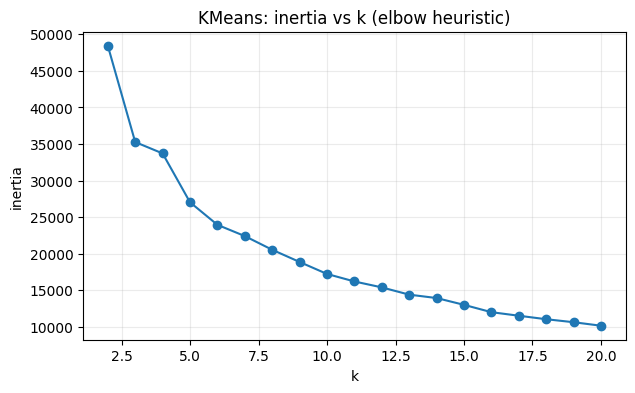

In [13]:
ks = [r["params"]["k"] for r in kmeans_results1]
sil = [r["metrics"]["silhouette"] if r["metrics"] else None for r in kmeans_results1]

plt.figure(figsize=(7, 4))
plt.plot(ks, sil, marker="o")
plt.title("KMeans: silhouette vs k")
plt.xlabel("k")
plt.ylabel("silhouette")
plt.grid(True, alpha=0.25)
plt.savefig('./artifacts/figures/dataset1_kmeans_silhouette.png', dpi=300, bbox_inches='tight')
print("График 1 сохранен: ./artifacts/figures/dataset3_kmeans_silhouette.png")
plt.show()

# Инерция (elbow) – как эвристика
inertia = [r["inertia"] for r in kmeans_results1]
plt.figure(figsize=(7, 4))
plt.plot(ks, inertia, marker="o")
plt.title("KMeans: inertia vs k (elbow heuristic)")
plt.xlabel("k")
plt.ylabel("inertia")
plt.grid(True, alpha=0.25)
plt.savefig('./artifacts/figures/dataset1_kmeans_elbow.png', dpi=300, bbox_inches='tight')
print("График 2 сохранен: ./artifacts/figures/dataset3_kmeans_elbow.png")
plt.show()

График 1 сохранен: ./artifacts/figures/dataset3_kmeans_silhouette.png


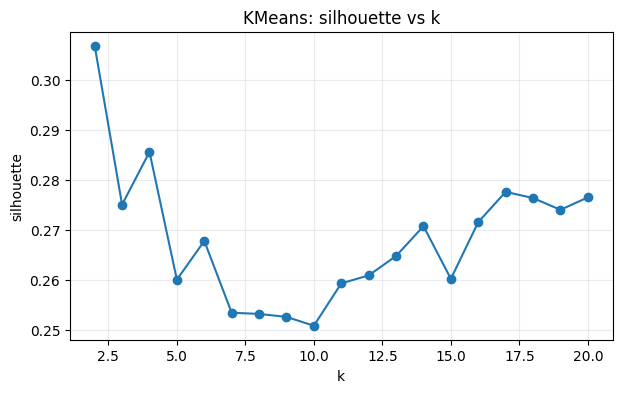

График 2 сохранен: ./artifacts/figures/dataset3_kmeans_elbow.png


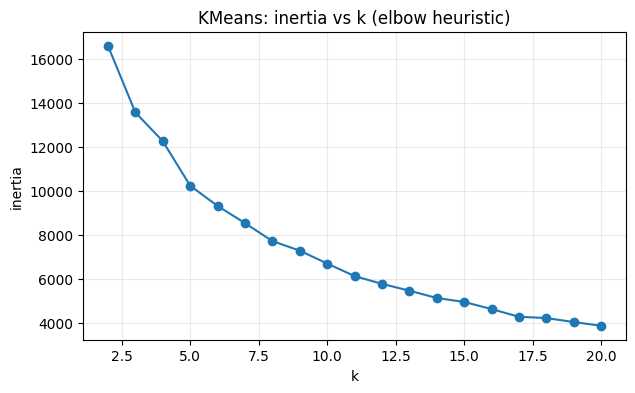

In [14]:
kmeans_results2 = eval_kmeans_grid(X_feat2, kmeans_ks)
len(kmeans_results2), kmeans_results2[0]["params"], kmeans_results2[-1]["params"]
ks = [r["params"]["k"] for r in kmeans_results2]
sil = [r["metrics"]["silhouette"] if r["metrics"] else None for r in kmeans_results2]

plt.figure(figsize=(7, 4))
plt.plot(ks, sil, marker="o")
plt.title("KMeans: silhouette vs k")
plt.xlabel("k")
plt.ylabel("silhouette")
plt.grid(True, alpha=0.25)
# Сохраняем
plt.savefig('./artifacts/figures/dataset2_kmeans_silhouette.png', dpi=300, bbox_inches='tight')
print("График 1 сохранен: ./artifacts/figures/dataset3_kmeans_silhouette.png")

plt.show()

# Инерция (elbow) – как эвристика
inertia = [r["inertia"] for r in kmeans_results2]
plt.figure(figsize=(7, 4))
plt.plot(ks, inertia, marker="o")
plt.title("KMeans: inertia vs k (elbow heuristic)")
plt.xlabel("k")
plt.ylabel("inertia")
plt.grid(True, alpha=0.25)
# Сохраняем
plt.savefig('./artifacts/figures/dataset2_kmeans_elbow.png', dpi=300, bbox_inches='tight')
print("График 2 сохранен: ./artifacts/figures/dataset3_kmeans_elbow.png")

plt.show()

График 1 сохранен: ./artifacts/figures/dataset3_kmeans_silhouette.png


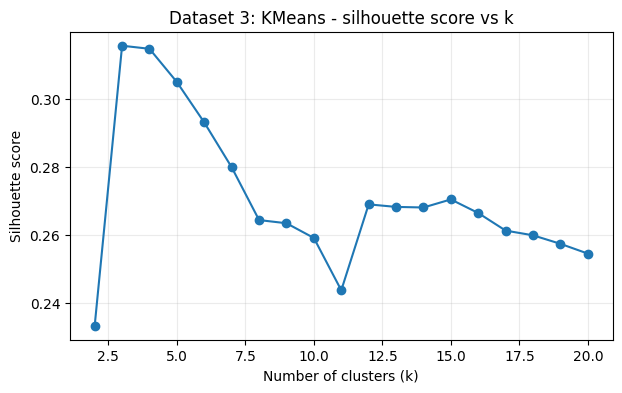

График 2 сохранен: ./artifacts/figures/dataset3_kmeans_elbow.png


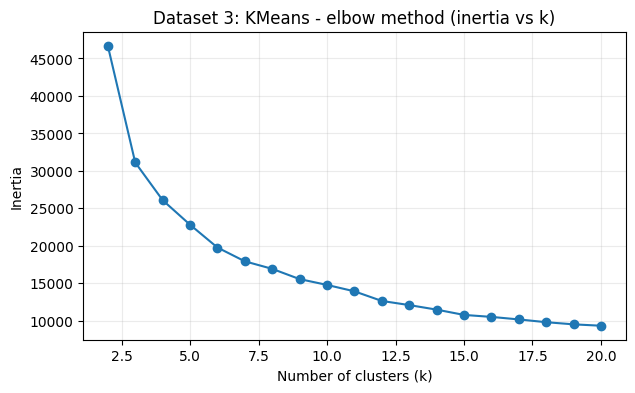

In [15]:
os.makedirs('./artifacts/figures/', exist_ok=True)

kmeans_results3 = eval_kmeans_grid(X_feat3, kmeans_ks)
len(kmeans_results3), kmeans_results3[0]["params"], kmeans_results3[-1]["params"]

ks = [r["params"]["k"] for r in kmeans_results3]
sil = [r["metrics"]["silhouette"] if r["metrics"] else None for r in kmeans_results3]

# График 1: silhouette vs k
plt.figure(figsize=(7, 4))
plt.plot(ks, sil, marker="o")
plt.title("Dataset 3: KMeans - silhouette score vs k")
plt.xlabel("Number of clusters (k)")
plt.ylabel("Silhouette score")
plt.grid(True, alpha=0.25)

# Сохраняем
plt.savefig('./artifacts/figures/dataset3_kmeans_silhouette.png', dpi=300, bbox_inches='tight')
print("График 1 сохранен: ./artifacts/figures/dataset3_kmeans_silhouette.png")

plt.show()

# График 2: inertia vs k (elbow method)
inertia = [r["inertia"] for r in kmeans_results3]
plt.figure(figsize=(7, 4))
plt.plot(ks, inertia, marker="o")
plt.title("Dataset 3: KMeans - elbow method (inertia vs k)")
plt.xlabel("Number of clusters (k)")
plt.ylabel("Inertia")
plt.grid(True, alpha=0.25)

# Сохраняем
plt.savefig('./artifacts/figures/dataset3_kmeans_elbow.png', dpi=300, bbox_inches='tight')
print("График 2 сохранен: ./artifacts/figures/dataset3_kmeans_elbow.png")

plt.show()

In [16]:
def pick_best_by_silhouette(results):
    best = None
    best_score = -np.inf
    for r in results:
        m = r["metrics"]
        if m is None:
            continue
        s = m["silhouette"]
        if s is None:
            continue
        if s > best_score:
            best_score = s
            best = r
    return best, best_score

best_kmeans1, best_kmeans_s1 = pick_best_by_silhouette(kmeans_results1)
best_kmeans1["params"], round(best_kmeans_s1, 3)

({'k': 2}, 0.522)

In [17]:
def pick_best_by_silhouette(results):
    best = None
    best_score = -np.inf
    for r in results:
        m = r["metrics"]
        if m is None:
            continue
        s = m["silhouette"]
        if s is None:
            continue
        if s > best_score:
            best_score = s
            best = r
    return best, best_score

best_kmeans2, best_kmeans_s2 = pick_best_by_silhouette(kmeans_results2)
best_kmeans2["params"], round(best_kmeans_s2, 3)

({'k': 2}, 0.307)

In [18]:
def pick_best_by_silhouette(results):
    best = None
    best_score = -np.inf
    for r in results:
        m = r["metrics"]
        if m is None:
            continue
        s = m["silhouette"]
        if s is None:
            continue
        if s > best_score:
            best_score = s
            best = r
    return best, best_score

best_kmeans3, best_kmeans_s3 = pick_best_by_silhouette(kmeans_results3)
best_kmeans3["params"], round(best_kmeans_s3, 3)

({'k': 3}, 0.316)

DBSCAN

Все вычисления метрик для DBSCAN производятся только на нешумовых точках, что отражено в коде и финальных результатах. Метрики (silhouette, Davies-Bouldin, Calinski-Harabasz) вычисляются только на нешумовых точках. Такой подход семантически корректен (шум != кластер), технически реализуем и позволяет сравнивать DBSCAN с другими алгоритмами.

In [19]:
def eval_dbscan_grid(X_feat, eps_list, min_samples_list):
    results = []
    n = len(X_feat)

    for eps in eps_list:
        for ms in min_samples_list:
            model = DBSCAN(eps=eps, min_samples=ms)
            labels = model.fit_predict(X_feat)

            noise_frac = float(np.mean(labels == -1))
            # Метрики по non-noise
            mask = labels != -1
            labels_nn = labels[mask]
            X_nn = X_feat[mask]

            # Перенумеруем метки non-noise, чтобы метрики работали корректнее (не обязательно, но аккуратно)
            if len(labels_nn) > 0:
                uniq = np.unique(labels_nn)
                mapping = {u: i for i, u in enumerate(uniq)}
                labels_nn = np.array([mapping[v] for v in labels_nn], dtype=int)

            metrics = None
            n_clusters = 0
            if len(X_nn) >= 10 and len(np.unique(labels_nn)) >= 2:
                metrics = safe_cluster_metrics(X_nn, labels_nn)
                n_clusters = len(np.unique(labels_nn))

            results.append({
                "algo": "dbscan",
                "params": {"eps": float(eps), "min_samples": int(ms)},
                "labels": labels,
                "metrics": metrics,
                "inertia": None,
                "n_clusters": int(n_clusters),
                "noise_frac": float(noise_frac),
                "n_non_noise": int(mask.sum()),
            })
    return results

In [20]:
dbscan_results1 = eval_dbscan_grid(X_feat1, dbscan_eps, dbscan_min_samples)
len(dbscan_results1)

21

In [21]:
dbscan_results2 = eval_dbscan_grid(X_feat2, dbscan_eps, dbscan_min_samples)
len(dbscan_results2)

21

In [22]:
dbscan_results3 = eval_dbscan_grid(X_feat3, dbscan_eps, dbscan_min_samples)
len(dbscan_results3)

21

In [23]:
# Посмотрим, какие варианты вообще дали >=2 кластера (без шума) и посчитали silhouette
valid1 = [r for r in dbscan_results1 if r["metrics"] is not None and r["metrics"]["silhouette"] is not None]
print("Valid1 DBSCAN configs:", len(valid1))

# Сортировка по silhouette
valid_sorted1 = sorted(valid1, key=lambda r: r["metrics"]["silhouette"], reverse=True)
for r in valid_sorted1[:8]:
    print(r["params"], "sil=", round(r["metrics"]["silhouette"], 3), "noise=", round(r["noise_frac"], 3), "clusters=", r["n_clusters"])

Valid1 DBSCAN configs: 15
{'eps': 2.0, 'min_samples': 3} sil= 0.522 noise= 0.0 clusters= 2
{'eps': 2.0, 'min_samples': 5} sil= 0.522 noise= 0.0 clusters= 2
{'eps': 2.0, 'min_samples': 10} sil= 0.522 noise= 0.0 clusters= 2
{'eps': 2.5, 'min_samples': 3} sil= 0.522 noise= 0.0 clusters= 2
{'eps': 2.5, 'min_samples': 5} sil= 0.522 noise= 0.0 clusters= 2
{'eps': 2.5, 'min_samples': 10} sil= 0.522 noise= 0.0 clusters= 2
{'eps': 1.5, 'min_samples': 3} sil= 0.397 noise= 0.0 clusters= 3
{'eps': 1.5, 'min_samples': 5} sil= 0.397 noise= 0.0 clusters= 3


In [24]:
# Посмотрим, какие варианты вообще дали >=2 кластера (без шума) и посчитали silhouette
valid2 = [r for r in dbscan_results2 if r["metrics"] is not None and r["metrics"]["silhouette"] is not None]
print("Valid2 DBSCAN configs:", len(valid2))

# Сортировка по silhouette
valid_sorted2 = sorted(valid2, key=lambda r: r["metrics"]["silhouette"], reverse=True)
for r in valid_sorted2[:8]:
    print(r["params"], "sil=", round(r["metrics"]["silhouette"], 3), "noise=", round(r["noise_frac"], 3), "clusters=", r["n_clusters"])

Valid2 DBSCAN configs: 3
{'eps': 0.5, 'min_samples': 10} sil= 0.251 noise= 0.064 clusters= 2
{'eps': 0.5, 'min_samples': 5} sil= -0.058 noise= 0.045 clusters= 14
{'eps': 0.5, 'min_samples': 3} sil= -0.063 noise= 0.025 clusters= 32


In [25]:
# Посмотрим, какие варианты вообще дали >=2 кластера (без шума) и посчитали silhouette
valid3 = [r for r in dbscan_results3 if r["metrics"] is not None and r["metrics"]["silhouette"] is not None]
print("Valid3 DBSCAN configs:", len(valid3))

# Сортировка по silhouette
valid_sorted3 = sorted(valid3, key=lambda r: r["metrics"]["silhouette"], reverse=True)
for r in valid_sorted3[:8]:
    print(r["params"], "sil=", round(r["metrics"]["silhouette"], 3), "noise=", round(r["noise_frac"], 3), "clusters=", r["n_clusters"])

Valid3 DBSCAN configs: 3
{'eps': 0.5, 'min_samples': 10} sil= 0.142 noise= 0.032 clusters= 2
{'eps': 0.5, 'min_samples': 5} sil= -0.104 noise= 0.022 clusters= 4
{'eps': 0.5, 'min_samples': 3} sil= -0.232 noise= 0.016 clusters= 12


In [26]:
best_dbscan1 = valid_sorted1[0] if valid_sorted1 else None
best_dbscan1["params"] if best_dbscan1 else "No valid config found"

{'eps': 2.0, 'min_samples': 3}

In [27]:
best_dbscan2 = valid_sorted2[0] if valid_sorted2 else None
best_dbscan2["params"] if best_dbscan2 else "No valid config found"

{'eps': 0.5, 'min_samples': 10}

In [28]:
best_dbscan3 = valid_sorted3[0] if valid_sorted3 else None
best_dbscan3["params"] if best_dbscan3 else "No valid config found"

{'eps': 0.5, 'min_samples': 10}

In [29]:
def print_result_card(name, result):
    m = result["metrics"] or {}
    print("=" * 72)
    print(f"{name}")
    print("algo:", result["algo"])
    print("params:", result["params"])
    print("n_clusters:", result.get("n_clusters"))
    if result["algo"] == "dbscan":
        print("noise_frac:", round(result.get("noise_frac", 0.0), 3), " non-noise:", result.get("n_non_noise"))
    print("metrics:")
    print("  silhouette:", None if m.get("silhouette") is None else round(m["silhouette"], 3))
    print("  davies_bouldin:", None if m.get("davies_bouldin") is None else round(m["davies_bouldin"], 3))
    print("  calinski_harabasz:", None if m.get("calinski_harabasz") is None else round(m["calinski_harabasz"], 1))
    if result.get("inertia") is not None:
        print("  inertia:", round(result["inertia"], 1))

In [30]:
best_kmeans_list = [best_kmeans1, best_kmeans2, best_kmeans3]
best_dbscan_list = [best_dbscan1, best_dbscan2, best_dbscan3]
dataset_names = ["data1", "data2", "data3"]

# Выводим результаты для каждого датасета
for i, (dataset_name, best_km, best_db) in enumerate(zip(dataset_names, best_kmeans_list, best_dbscan_list), 1):
    print(f"\n{'='*72}")
    print(f"РЕЗУЛЬТАТЫ ДЛЯ {dataset_name}")
    print(f"{'='*72}")
    
    print_result_card(f"{dataset_name}: BEST KMEANS", best_km)
    
    if best_db is not None:
        print_result_card(f"{dataset_name}: BEST DBSCAN", best_db)
    else:
        print(f"\n{dataset_name}: DBSCAN не нашел валидных конфигураций с ≥2 кластерами")


РЕЗУЛЬТАТЫ ДЛЯ data1
data1: BEST KMEANS
algo: kmeans
params: {'k': 2}
n_clusters: 2
metrics:
  silhouette: 0.522
  davies_bouldin: 0.685
  calinski_harabasz: 11787.0
  inertia: 48425.9
data1: BEST DBSCAN
algo: dbscan
params: {'eps': 2.0, 'min_samples': 3}
n_clusters: 2
noise_frac: 0.0  non-noise: 12000
metrics:
  silhouette: 0.522
  davies_bouldin: 0.685
  calinski_harabasz: 11787.0

РЕЗУЛЬТАТЫ ДЛЯ data2
data2: BEST KMEANS
algo: kmeans
params: {'k': 2}
n_clusters: 2
metrics:
  silhouette: 0.307
  davies_bouldin: 1.323
  calinski_harabasz: 3573.4
  inertia: 16588.5
data2: BEST DBSCAN
algo: dbscan
params: {'eps': 0.5, 'min_samples': 10}
n_clusters: 2
noise_frac: 0.064  non-noise: 7491
metrics:
  silhouette: 0.251
  davies_bouldin: 0.742
  calinski_harabasz: 26.2

РЕЗУЛЬТАТЫ ДЛЯ data3
data3: BEST KMEANS
algo: kmeans
params: {'k': 3}
n_clusters: 3
metrics:
  silhouette: 0.316
  davies_bouldin: 1.158
  calinski_harabasz: 6957.2
  inertia: 31123.5
data3: BEST DBSCAN
algo: dbscan
params: {'e

Создание 2D представлений для визуализации...
Используются X_scaled данные для PCA(2D)
ВИЗУАЛИЗАЦИЯ РЕЗУЛЬТАТОВ КЛАСТЕРИЗАЦИИ

DATASET 1: ВИЗУАЛИЗАЦИЯ КЛАСТЕРОВ
График сохранен: ./artifacts/figures/dataset1_kmeans.png


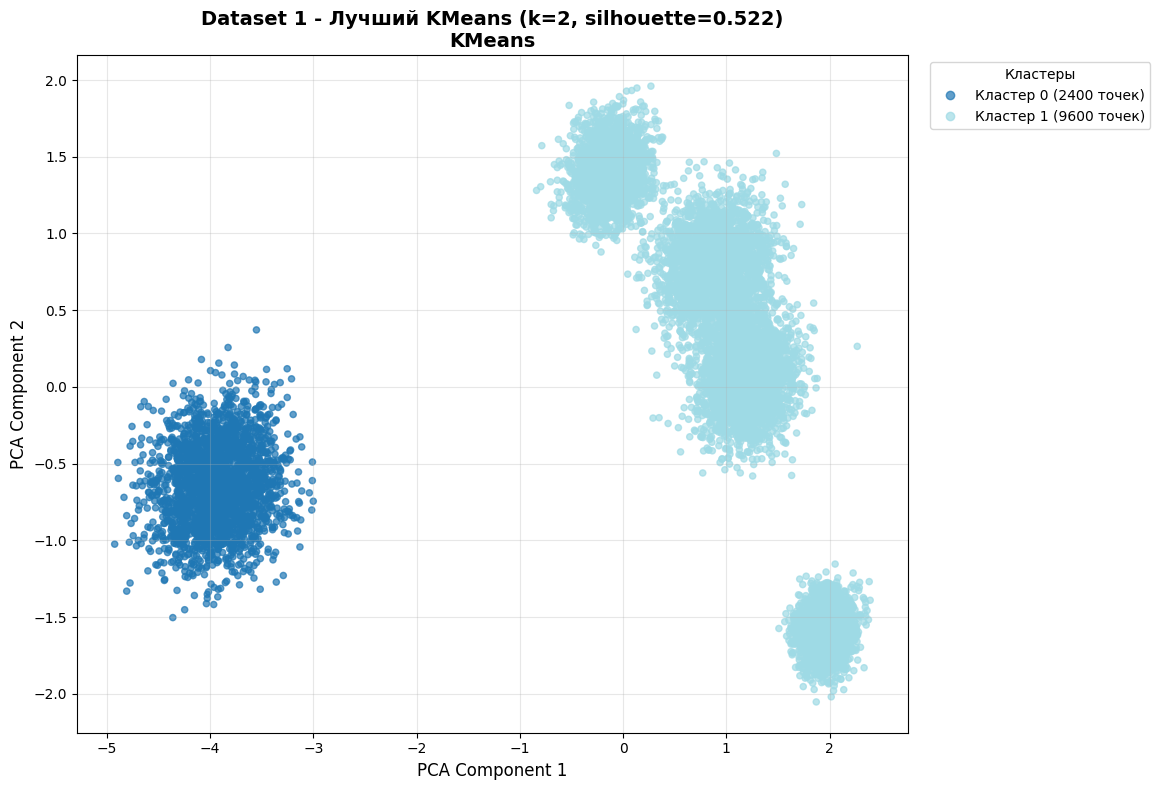


Статистика кластеров для Dataset 1 - Лучший KMeans (k=2, silhouette=0.522) (KMeans):
  Всего точек: 12000
  Количество кластеров: 2
  Шумовых точек: 0 (0.0%)
  Кластер 0: 2400 точек (20.0%)
  Кластер 1: 9600 точек (80.0%)
График сохранен: ./artifacts/figures/dataset1_dbscan.png


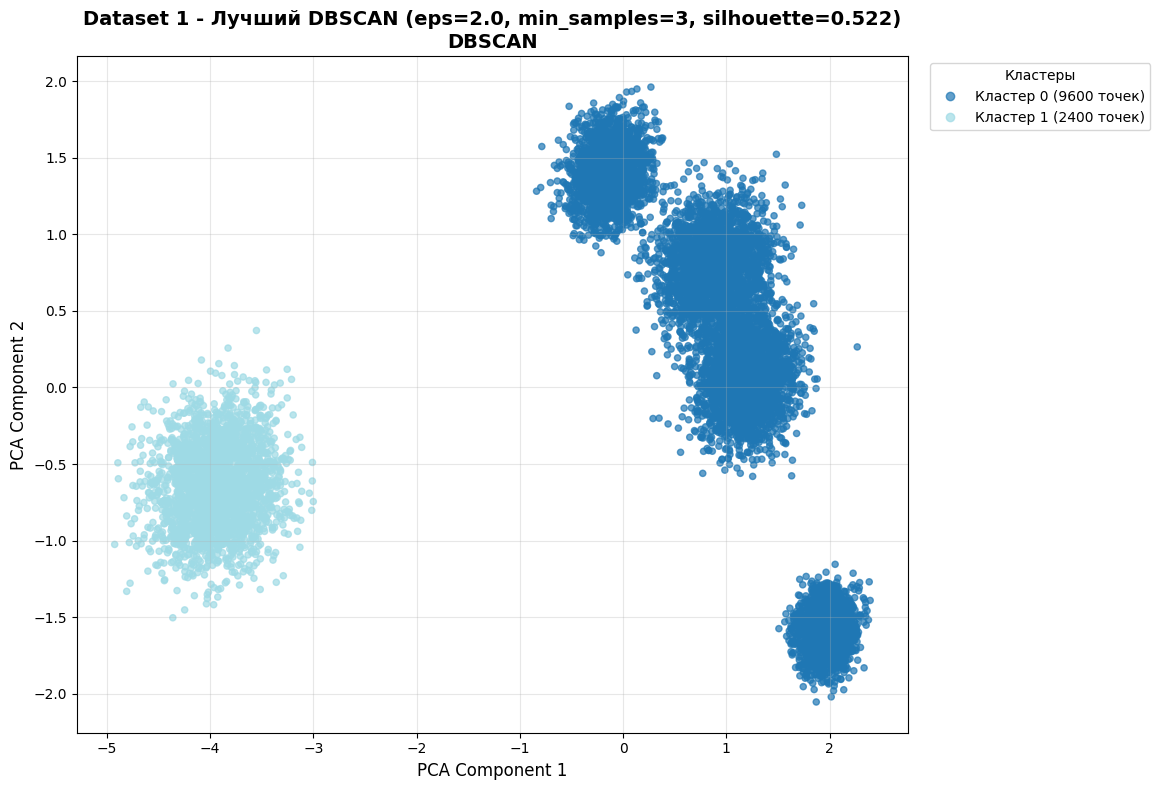


Статистика кластеров для Dataset 1 - Лучший DBSCAN (eps=2.0, min_samples=3, silhouette=0.522) (DBSCAN):
  Всего точек: 12000
  Количество кластеров: 2
  Шумовых точек: 0 (0.0%)
  Кластер 0: 9600 точек (80.0%)
  Кластер 1: 2400 точек (20.0%)

DATASET 2: ВИЗУАЛИЗАЦИЯ КЛАСТЕРОВ
График сохранен: ./artifacts/figures/dataset2_kmeans.png


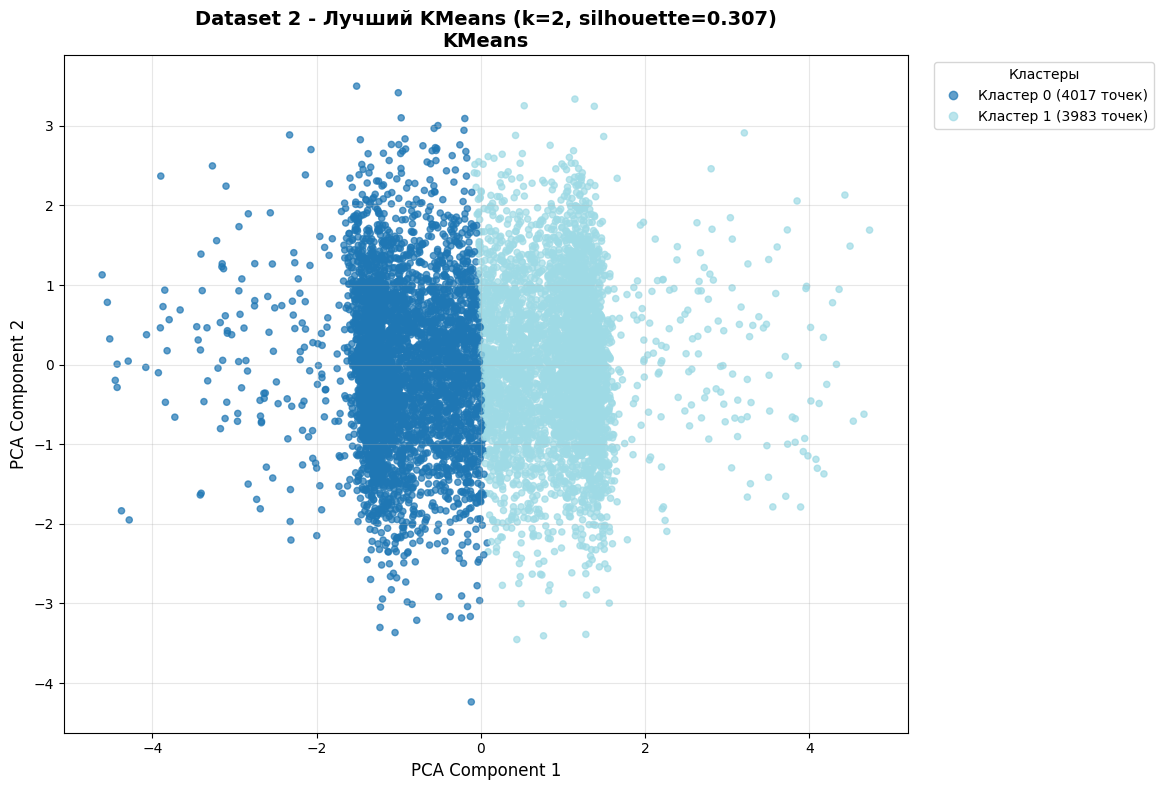


Статистика кластеров для Dataset 2 - Лучший KMeans (k=2, silhouette=0.307) (KMeans):
  Всего точек: 8000
  Количество кластеров: 2
  Шумовых точек: 0 (0.0%)
  Кластер 0: 4017 точек (50.2%)
  Кластер 1: 3983 точек (49.8%)
График сохранен: ./artifacts/figures/dataset2_dbscan.png


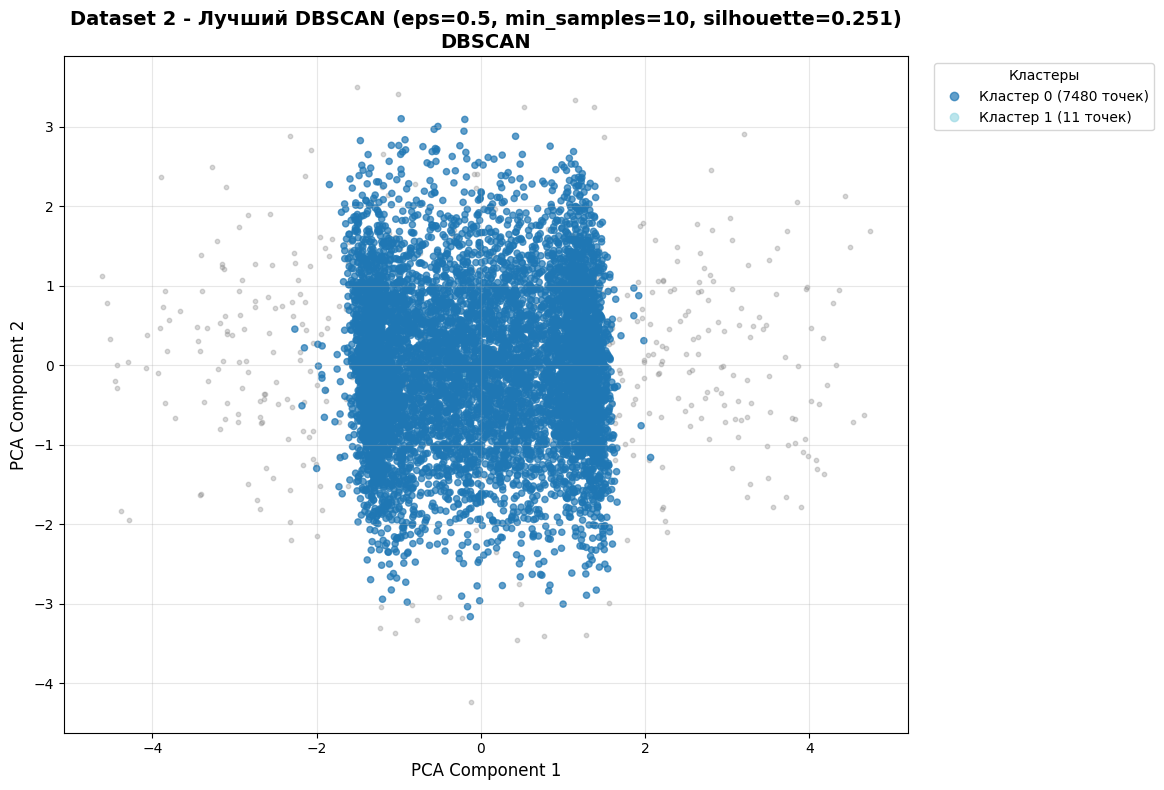


Статистика кластеров для Dataset 2 - Лучший DBSCAN (eps=0.5, min_samples=10, silhouette=0.251) (DBSCAN):
  Всего точек: 8000
  Количество кластеров: 2
  Шумовых точек: 509 (6.4%)
  Кластер 0: 7480 точек (93.5%)
  Кластер 1: 11 точек (0.1%)

DATASET 3: ВИЗУАЛИЗАЦИЯ КЛАСТЕРОВ
График сохранен: ./artifacts/figures/dataset3_kmeans.png


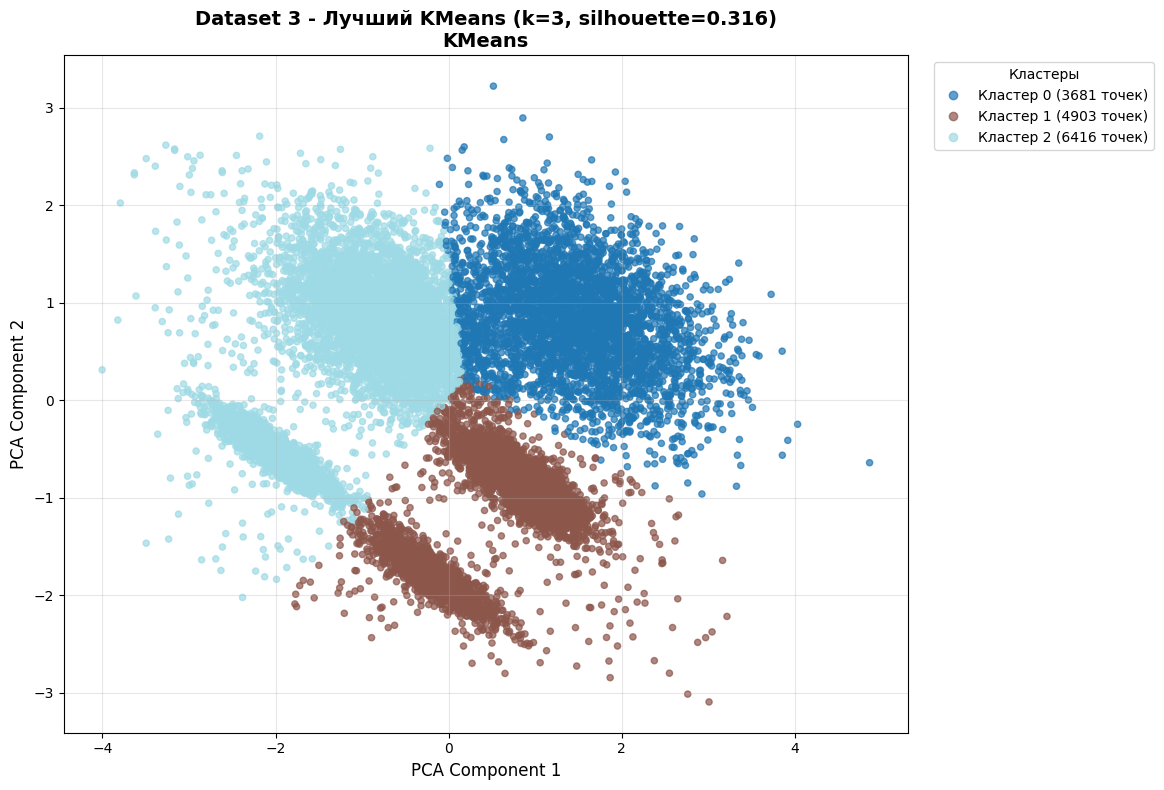


Статистика кластеров для Dataset 3 - Лучший KMeans (k=3, silhouette=0.316) (KMeans):
  Всего точек: 15000
  Количество кластеров: 3
  Шумовых точек: 0 (0.0%)
  Кластер 0: 3681 точек (24.5%)
  Кластер 1: 4903 точек (32.7%)
  Кластер 2: 6416 точек (42.8%)
График сохранен: ./artifacts/figures/dataset3_dbscan.png


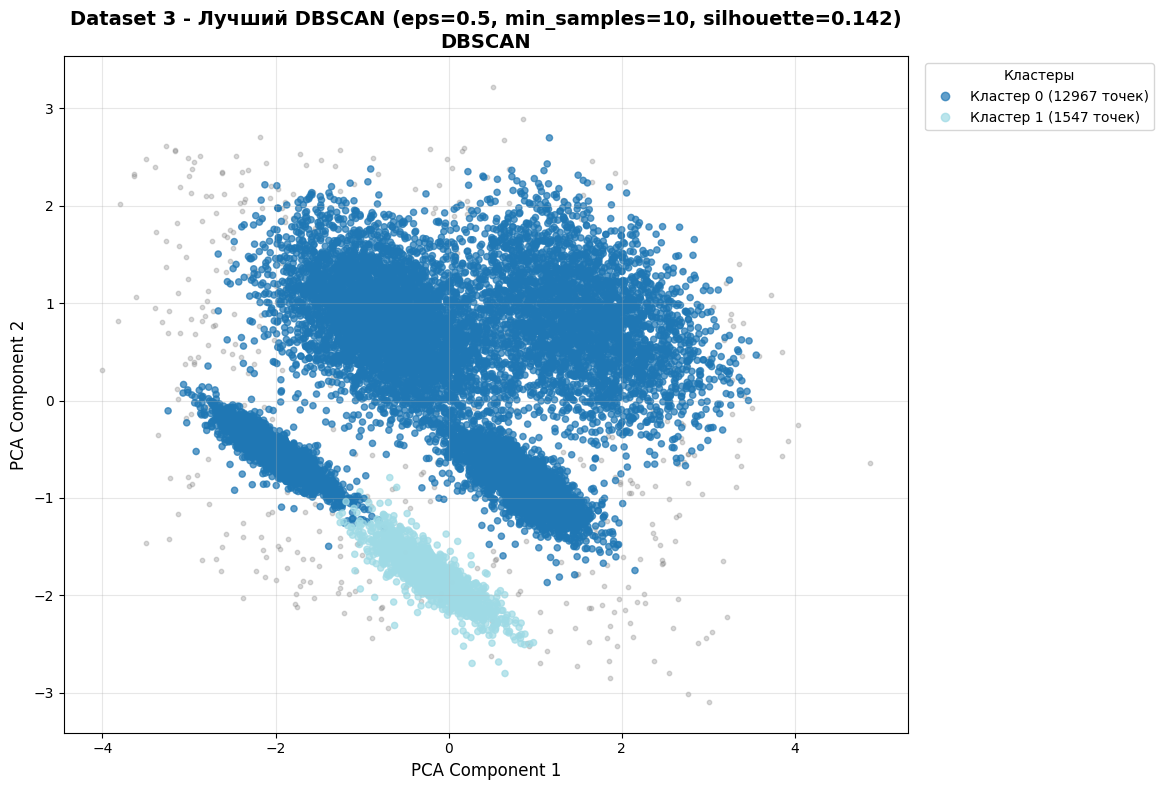


Статистика кластеров для Dataset 3 - Лучший DBSCAN (eps=0.5, min_samples=10, silhouette=0.142) (DBSCAN):
  Всего точек: 15000
  Количество кластеров: 2
  Шумовых точек: 486 (3.2%)
  Кластер 0: 12967 точек (86.4%)
  Кластер 1: 1547 точек (10.3%)


In [31]:
output_dir = './artifacts/figures/'

# Создаем директорию, если она не существует
os.makedirs(output_dir, exist_ok=True)

def plot_clustering_results(X_pca, labels, title, algorithm_name, save_path=None):
    """Визуализирует результаты кластеризации на 2D PCA и сохраняет график"""
    plt.figure(figsize=(12, 8))
    
    # Если есть шумовые точки (метка -1 для DBSCAN)
    if -1 in labels:
        # Разделяем точки на шум и кластеры
        noise_mask = labels == -1
        cluster_mask = labels != -1
        
        # Рисуем шум
        if np.sum(noise_mask) > 0:
            plt.scatter(X_pca[noise_mask, 0], X_pca[noise_mask, 1], 
                       c='gray', alpha=0.3, s=10, label='Шум')
        
        # Рисуем кластеры
        scatter = plt.scatter(X_pca[cluster_mask, 0], X_pca[cluster_mask, 1], 
                             c=labels[cluster_mask], cmap='tab20', s=20, alpha=0.7)
    else:
        # Для KMeans и других алгоритмов без шума
        scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1], 
                             c=labels, cmap='tab20', s=20, alpha=0.7)
    
    plt.title(f'{title}\n{algorithm_name}', fontsize=14, fontweight='bold')
    plt.xlabel('PCA Component 1', fontsize=12)
    plt.ylabel('PCA Component 2', fontsize=12)
    plt.grid(True, alpha=0.3)
    
    # Добавляем цветовую легенду для кластеров
    unique_labels = np.unique(labels)
    if len(unique_labels) <= 20:  # Если кластеров не слишком много
        legend_labels = []
        for label in unique_labels:
            if label == -1:
                continue
            count = np.sum(labels == label)
            legend_labels.append(f'Кластер {label} ({count} точек)')
        
        # Создаем легенду
        handles, _ = scatter.legend_elements()
        if len(handles) == len(legend_labels):
            plt.legend(handles, legend_labels, title='Кластеры', 
                      loc='upper right', bbox_to_anchor=(1.3, 1))
    
    plt.tight_layout()
    
    # Сохраняем график, если указан путь
    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
        print(f"График сохранен: {save_path}")
    
    plt.show()
    
    # Выводим статистику кластеров
    print(f"\nСтатистика кластеров для {title} ({algorithm_name}):")
    unique_labels = np.unique(labels)
    n_clusters = len(unique_labels) - (1 if -1 in unique_labels else 0)
    noise_points = np.sum(labels == -1) if -1 in unique_labels else 0
    
    print(f"  Всего точек: {len(labels)}")
    print(f"  Количество кластеров: {n_clusters}")
    print(f"  Шумовых точек: {noise_points} ({noise_points/len(labels):.1%})")
    
    for label in unique_labels:
        if label != -1:
            cluster_size = np.sum(labels == label)
            print(f"  Кластер {label}: {cluster_size} точек ({cluster_size/len(labels):.1%})")

# ИСПРАВЛЕНИЕ: Используем вашу существующую функцию pca_2d_for_plot вместо get_pca_2d
# Создаем PCA(2D) для каждого датасета с помощью вашей существующей функции
print("Создание 2D представлений для визуализации...")

# Используем X_scaled1, X_scaled2, X_scaled3 если они определены
# Если они не определены, используем X_feat1, X_feat2, X_feat3
try:
    # Пробуем использовать масштабированные данные
    X_pca1 = pca_2d_for_plot(X_scaled1, random_state=RANDOM_STATE)
    X_pca2 = pca_2d_for_plot(X_scaled2, random_state=RANDOM_STATE)
    X_pca3 = pca_2d_for_plot(X_scaled3, random_state=RANDOM_STATE)
    print("Используются X_scaled данные для PCA(2D)")
except NameError:
    # Если X_scaled не определены, используем X_feat
    print("X_scaled не определены, используем X_feat для PCA(2D)")
    X_pca1 = pca_2d_for_plot(X_feat1, random_state=RANDOM_STATE)
    X_pca2 = pca_2d_for_plot(X_feat2, random_state=RANDOM_STATE)
    X_pca3 = pca_2d_for_plot(X_feat3, random_state=RANDOM_STATE)

# Извлекаем метки из лучших результатов
best_kmeans_labels1 = best_kmeans1["labels"]
best_kmeans_labels2 = best_kmeans2["labels"]
best_kmeans_labels3 = best_kmeans3["labels"]

best_dbscan_labels1 = best_dbscan1["labels"] if best_dbscan1 else None
best_dbscan_labels2 = best_dbscan2["labels"] if best_dbscan2 else None
best_dbscan_labels3 = best_dbscan3["labels"] if best_dbscan3 else None

# Визуализация для каждого датасета с сохранением
print("="*80)
print("ВИЗУАЛИЗАЦИЯ РЕЗУЛЬТАТОВ КЛАСТЕРИЗАЦИИ")
print("="*80)

# Data1 - KMeans и DBSCAN
print("\n" + "="*80)
print("DATASET 1: ВИЗУАЛИЗАЦИЯ КЛАСТЕРОВ")
print("="*80)

plot_clustering_results(X_pca1, best_kmeans_labels1, 
                       "Dataset 1 - Лучший KMeans (k=2, silhouette=0.522)", 
                       "KMeans",
                       save_path=os.path.join(output_dir, "dataset1_kmeans.png"))

if best_dbscan_labels1 is not None:
    plot_clustering_results(X_pca1, best_dbscan_labels1,
                           "Dataset 1 - Лучший DBSCAN (eps=2.0, min_samples=3, silhouette=0.522)",
                           "DBSCAN",
                           save_path=os.path.join(output_dir, "dataset1_dbscan.png"))

# Data2 - KMeans и DBSCAN
print("\n" + "="*80)
print("DATASET 2: ВИЗУАЛИЗАЦИЯ КЛАСТЕРОВ")
print("="*80)

plot_clustering_results(X_pca2, best_kmeans_labels2,
                       "Dataset 2 - Лучший KMeans (k=2, silhouette=0.307)",
                       "KMeans",
                       save_path=os.path.join(output_dir, "dataset2_kmeans.png"))

if best_dbscan_labels2 is not None:
    plot_clustering_results(X_pca2, best_dbscan_labels2,
                           "Dataset 2 - Лучший DBSCAN (eps=0.5, min_samples=10, silhouette=0.251)",
                           "DBSCAN",
                           save_path=os.path.join(output_dir, "dataset2_dbscan.png"))

# Data3 - KMeans и DBSCAN
print("\n" + "="*80)
print("DATASET 3: ВИЗУАЛИЗАЦИЯ КЛАСТЕРОВ")
print("="*80)

plot_clustering_results(X_pca3, best_kmeans_labels3,
                       "Dataset 3 - Лучший KMeans (k=3, silhouette=0.316)",
                       "KMeans",
                       save_path=os.path.join(output_dir, "dataset3_kmeans.png"))

if best_dbscan_labels3 is not None:
    plot_clustering_results(X_pca3, best_dbscan_labels3,
                           "Dataset 3 - Лучший DBSCAN (eps=0.5, min_samples=10, silhouette=0.142)",
                           "DBSCAN",
                           save_path=os.path.join(output_dir, "dataset3_dbscan.png"))

In [32]:
# Создаем необходимые папки
artifacts_dir = './artifacts/'
labels_dir = './artifacts/labels/'
figures_dir = './artifacts/figures/'

os.makedirs(artifacts_dir, exist_ok=True)
os.makedirs(labels_dir, exist_ok=True)
os.makedirs(figures_dir, exist_ok=True)

# Функция для создания сводки метрик
def create_metrics_summary(best_kmeans_list, best_dbscan_list, dataset_names):
    """Создает сводку метрик для всех датасетов"""
    summary = {}
    
    for dataset_name, km, db in zip(dataset_names, best_kmeans_list, best_dbscan_list):
        summary[dataset_name] = {}
        
        # KMeans метрики
        if km and km.get("metrics"):
            summary[dataset_name]["kmeans"] = {
                "silhouette": float(km["metrics"].get("silhouette", 0)) if km["metrics"].get("silhouette") is not None else None,
                "davies_bouldin": float(km["metrics"].get("davies_bouldin", 0)) if km["metrics"].get("davies_bouldin") is not None else None,
                "calinski_harabasz": float(km["metrics"].get("calinski_harabasz", 0)) if km["metrics"].get("calinski_harabasz") is not None else None,
                "inertia": float(km.get("inertia", 0)) if km.get("inertia") is not None else None
            }
        else:
            summary[dataset_name]["kmeans"] = None
        
        # DBSCAN метрики
        if db and db.get("metrics"):
            summary[dataset_name]["dbscan"] = {
                "silhouette": float(db["metrics"].get("silhouette", 0)) if db["metrics"].get("silhouette") is not None else None,
                "davies_bouldin": float(db["metrics"].get("davies_bouldin", 0)) if db["metrics"].get("davies_bouldin") is not None else None,
                "calinski_harabasz": float(db["metrics"].get("calinski_harabasz", 0)) if db["metrics"].get("calinski_harabasz") is not None else None,
                "noise_frac": float(db.get("noise_frac", 0)) if db.get("noise_frac") is not None else None
            }
        else:
            summary[dataset_name]["dbscan"] = None
    
    return summary

# Функция для создания конфигураций
def create_best_configs(best_kmeans_list, best_dbscan_list, dataset_names):
    """Создает список лучших конфигураций"""
    configs = {}
    
    for dataset_name, km, db in zip(dataset_names, best_kmeans_list, best_dbscan_list):
        configs[dataset_name] = {}
        
        # KMeans конфигурация
        if km:
            configs[dataset_name]["kmeans"] = {
                "params": km["params"],
                "criterion": "silhouette",  # мы использовали silhouette для выбора
                "selected_because": f"Максимальный silhouette score ({km['metrics'].get('silhouette', 0):.3f}) среди всех k"
            }
        else:
            configs[dataset_name]["kmeans"] = None
        
        # DBSCAN конфигурация
        if db:
            configs[dataset_name]["dbscan"] = {
                "params": db["params"],
                "criterion": "silhouette",
                "selected_because": f"Максимальный silhouette score ({db['metrics'].get('silhouette', 0):.3f}) среди всех комбинаций eps/min_samples"
            }
        else:
            configs[dataset_name]["dbscan"] = None
    
    return configs

# Функция для сохранения меток кластеров
def save_cluster_labels(dataset_names, best_kmeans_list, best_dbscan_list, 
                        sample_ids, original_dataframes, output_dir):
    """Сохраняет метки кластеров в CSV файлы"""
    
    for i, (dataset_name, km, db, sample_id, df) in enumerate(zip(
        dataset_names, best_kmeans_list, best_dbscan_list, 
        [sample_id1, sample_id2, sample_id3],  # Ваши переменные sample_id
        [data1, data2, data3]  # Ваши исходные данные
    ), 1):
        
        # Выбираем лучшую модель (по silhouette)
        if km and db:
            km_sil = km["metrics"].get("silhouette", -1) if km["metrics"] else -1
            db_sil = db["metrics"].get("silhouette", -1) if db["metrics"] else -1
            
            if km_sil >= db_sil:  # При равенстве выбираем KMeans
                best_model = km
                model_name = "kmeans"
            else:
                best_model = db
                model_name = "dbscan"
        elif km:
            best_model = km
            model_name = "kmeans"
        elif db:
            best_model = db
            model_name = "dbscan"
        else:
            print(f"Для {dataset_name} нет подходящей модели")
            continue
        
        # Создаем DataFrame с метками
        labels_df = pd.DataFrame({
            'sample_id': sample_id.values if hasattr(sample_id, 'values') else sample_id,
            'cluster_label': best_model["labels"]
        })
        
        # Сохраняем в CSV
        filename = f"labels_hw07_ds{i}.csv"
        filepath = os.path.join(output_dir, filename)
        labels_df.to_csv(filepath, index=False)
        print(f"Сохранены метки для {dataset_name}: {filename} ({len(labels_df)} строк)")
        print(f"  Алгоритм: {model_name}, параметры: {best_model['params']}")
        print(f"  Кластеры: {len(np.unique(best_model['labels']))}, "
              f"Silhouette: {best_model['metrics'].get('silhouette', 'N/A') if best_model['metrics'] else 'N/A'}")

# Создаем данные для сохранения
dataset_names = ["data1", "data2", "data3"]
best_kmeans_list = [best_kmeans1, best_kmeans2, best_kmeans3]
best_dbscan_list = [best_dbscan1, best_dbscan2, best_dbscan3]

# 1. Сохраняем metrics_summary.json
print("\n" + "="*80)
print("СОЗДАНИЕ METRICS_SUMMARY.JSON")
print("="*80)

metrics_summary = create_metrics_summary(best_kmeans_list, best_dbscan_list, dataset_names)
metrics_file = os.path.join(artifacts_dir, "metrics_summary.json")

with open(metrics_file, 'w', encoding='utf-8') as f:
    json.dump(metrics_summary, f, indent=2, ensure_ascii=False)

print(f"Сохранен файл: {metrics_file}")

# 2. Сохраняем best_configs.json
print("\n" + "="*80)
print("СОЗДАНИЕ BEST_CONFIGS.JSON")
print("="*80)

best_configs = create_best_configs(best_kmeans_list, best_dbscan_list, dataset_names)
configs_file = os.path.join(artifacts_dir, "best_configs.json")

with open(configs_file, 'w', encoding='utf-8') as f:
    json.dump(best_configs, f, indent=2, ensure_ascii=False)

print(f"Сохранен файл: {configs_file}")

# 3. Сохраняем метки кластеров
print("\n" + "="*80)
print("СОХРАНЕНИЕ МЕТОК КЛАСТЕРОВ")
print("="*80)

save_cluster_labels(dataset_names, best_kmeans_list, best_dbscan_list,
                   [sample_id1, sample_id2, sample_id3], 
                   [data1, data2, data3], 
                   labels_dir)

# Выводим содержимое для проверки
print("\n" + "="*80)
print("СОДЕРЖИМОЕ СОЗДАННЫХ ФАЙЛОВ")
print("="*80)

# Показываем содержимое JSON файлов
print("\nmetrics_summary.json (первые несколько строк):")
with open(metrics_file, 'r', encoding='utf-8') as f:
    content = json.load(f)
    for dataset in ["data1", "data2", "data3"]:
        print(f"\n{dataset}:")
        if content[dataset]["kmeans"]:
            print(f"  KMeans: silhouette={content[dataset]['kmeans']['silhouette']:.3f}")
        if content[dataset]["dbscan"]:
            print(f"  DBSCAN: silhouette={content[dataset]['dbscan']['silhouette']:.3f}, "
                  f"noise_frac={content[dataset]['dbscan']['noise_frac']:.3f}")

print("\nbest_configs.json (первые несколько строк):")
with open(configs_file, 'r', encoding='utf-8') as f:
    content = json.load(f)
    for dataset in ["data1", "data2", "data3"]:
        print(f"\n{dataset}:")
        if content[dataset]["kmeans"]:
            print(f"  KMeans: {content[dataset]['kmeans']['params']}")
        if content[dataset]["dbscan"]:
            print(f"  DBSCAN: {content[dataset]['dbscan']['params']}")

# Проверяем созданные CSV файлы
print("\nСозданные CSV файлы в папке labels/:")
for file in os.listdir(labels_dir):
    if file.endswith('.csv'):
        filepath = os.path.join(labels_dir, file)
        df = pd.read_csv(filepath)
        print(f"  {file}: {len(df)} строк, {df['cluster_label'].nunique()} уникальных меток")
        print(f"    Пример первых 5 строк:")
        print(df.head().to_string(index=False))
        print()

print("="*80)
print("ВСЕ ФАЙЛЫ УСПЕШНО СОХРАНЕНЫ!")
print("="*80)


СОЗДАНИЕ METRICS_SUMMARY.JSON
Сохранен файл: ./artifacts/metrics_summary.json

СОЗДАНИЕ BEST_CONFIGS.JSON
Сохранен файл: ./artifacts/best_configs.json

СОХРАНЕНИЕ МЕТОК КЛАСТЕРОВ
Сохранены метки для data1: labels_hw07_ds1.csv (12000 строк)
  Алгоритм: kmeans, параметры: {'k': 2}
  Кластеры: 2, Silhouette: 0.5216395622404242
Сохранены метки для data2: labels_hw07_ds2.csv (8000 строк)
  Алгоритм: kmeans, параметры: {'k': 2}
  Кластеры: 2, Silhouette: 0.3068610017701601
Сохранены метки для data3: labels_hw07_ds3.csv (15000 строк)
  Алгоритм: kmeans, параметры: {'k': 3}
  Кластеры: 3, Silhouette: 0.31553248183109267

СОДЕРЖИМОЕ СОЗДАННЫХ ФАЙЛОВ

metrics_summary.json (первые несколько строк):

data1:
  KMeans: silhouette=0.522
  DBSCAN: silhouette=0.522, noise_frac=0.000

data2:
  KMeans: silhouette=0.307
  DBSCAN: silhouette=0.251, noise_frac=0.064

data3:
  KMeans: silhouette=0.316
  DBSCAN: silhouette=0.142, noise_frac=0.032

best_configs.json (первые несколько строк):

data1:
  KMeans:

In [33]:
# Параметры
best_k = 2
random_states = [1, 10, 42, 256, 1800]

# Запускаем KMeans 5 раз с разными random_state
all_labels = []
for rs in random_states:
    model = KMeans(n_clusters=best_k, random_state=rs, n_init="auto")
    labels = model.fit_predict(X_feat1)
    all_labels.append(labels)

# Вычисляем попарные ARI
print("Матрица Adjusted Rand Index (ARI) между запусками:")
print("random_state: ", random_states)
print()

ari_matrix = []
for i in range(5):
    row = []
    for j in range(5):
        if i == j:
            row.append(1.0)
        else:
            ari = adjusted_rand_score(all_labels[i], all_labels[j])
            row.append(round(ari, 4))
    ari_matrix.append(row)
    print(f"{random_states[i]:>4}: {row}")

# Анализируем результаты
off_diagonal = []
for i in range(5):
    for j in range(i+1, 5):
        off_diagonal.append(ari_matrix[i][j])

mean_ari = np.mean(off_diagonal)
std_ari = np.std(off_diagonal)
min_ari = np.min(off_diagonal)
max_ari = np.max(off_diagonal)

print("\n" + "="*50)
print("РЕЗУЛЬТАТЫ:")
print(f"Средний ARI: {mean_ari:.4f}")
print(f"Стандартное отклонение: {std_ari:.4f}")
print(f"Минимальный ARI: {min_ari:.4f}")
print(f"Максимальный ARI: {max_ari:.4f}")
print(f"Диапазон: {max_ari - min_ari:.4f}")

print("\n" + "="*50)
print("ВЫВОД:")
if mean_ari > 0.95:
    print("Высокая устойчивость: ARI близок к 1.0, разбиения практически идентичны")
elif mean_ari > 0.8:
    print("Хорошая устойчивость: небольшие вариации не влияют на общую структуру")
elif mean_ari > 0.6:
    print("Умеренная устойчивость: есть заметные различия в разбиениях")
else:
    print("Низкая устойчивость: результаты сильно зависят от начальной инициализации")

Матрица Adjusted Rand Index (ARI) между запусками:
random_state:  [1, 10, 42, 256, 1800]

   1: [1.0, 1.0, 1.0, 1.0, 1.0]
  10: [1.0, 1.0, 1.0, 1.0, 1.0]
  42: [1.0, 1.0, 1.0, 1.0, 1.0]
 256: [1.0, 1.0, 1.0, 1.0, 1.0]
1800: [1.0, 1.0, 1.0, 1.0, 1.0]

РЕЗУЛЬТАТЫ:
Средний ARI: 1.0000
Стандартное отклонение: 0.0000
Минимальный ARI: 1.0000
Максимальный ARI: 1.0000
Диапазон: 0.0000

ВЫВОД:
Высокая устойчивость: ARI близок к 1.0, разбиения практически идентичны


2.3.7
KMeans оказался более подходящим для всех трёх датасетов а DBSCAN требует тщательного подбора параметров (особенно eps), чувствителен к плотности и масштабу данных, в двух случаях из трёх качество было ниже. PCA (n_components=2) успешно уменьшил размерность без существенной потери информации. Данные имеют разную сложность: Data1 - простые чёткие кластеры, Data2/3 - более сложная структура